In [1]:
!pip install ~/fwiVis/utility_functions/

Processing /home/jovyan/fwiVis/utility_functions
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fwiVis: filename=fwivis-0.1-py3-none-any.whl size=5594 sha256=77e9e68a748321e887c714c75be96c366fa9d188e40033c3f90e7d1953dce95c
  Stored in directory: /tmp/pip-ephem-wheel-cache-ugr2eblf/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
import shapely
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain
from datetime import date
import matplotlib.dates as mdates
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.ticker import StrMethodFormatter

import seaborn as sn
sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

In [3]:
def get_centroid(df):
    df_tmp = df[~df.geometry.isnull()]
    df_tmp["farea_unitless"] = df_tmp.geometry.area
    max_u = df_tmp.farea_unitless.max()
    lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
    lon = df_tmp[df_tmp.farea_unitless == max_u].centroid.x
    #print(lat.iloc[0])
    df["lat_centroid"] = lat.iloc[0]
    df["lon_centroid"] = lon.iloc[0]
    return(df)



def diff_fix(df, col = "farea"):
    fid = "fire"
    df = df.sort_values(by = "t")
    df[col+ "_diff"] = df[col].diff()

    df[col+ "_diff_round"] = df[col+ "_diff"].round(4) ## Correcting for negatives introduced by numarical instabilities/ rounding differences and create very small negative numbers
    
    ### Go through and finding times when fire area is negative, checking for change in area from previous, and using that number as "merge ignition". 
    df["geometry_difference_manual"] = None
    df["area_from_geometry_difference_manual"] = None
    fireID_t_pairs = df.loc[(df.farea_diff_round < 0), ["t"]].reset_index(drop = True)
    for i in range(0, len(fireID_t_pairs)):
        t = str(fireID_t_pairs.iloc[i].iloc[0])
        t_obj = datetime.strptime(t, "%Y-%m-%d %H:%M:%S")
        t_previous = t_obj - timedelta(hours=12)
        t_previous = t_previous.strftime("%Y-%m-%d %H:%M:%S")
        row_mask_t =  (df.t == t)
        row_mask_t_prev =  (df.t == t_previous)
        if( len(df.loc[row_mask_t_prev, "geometry"]) == 0 ):
            print(f"Warning: {fid} does not have t {t_previous}. Trying timestep 12 hours earlier.")
            t_previous = t_obj - timedelta(hours=24)
            t_previous = t_previous.strftime("%Y-%m-%d %H:%M:%S")
            row_mask_t_prev = (df.t == t_previous)
            if(len(df.loc[row_mask_t_prev, "geometry"]) == 0 ):
                print(f"Warning: {fid} STILL does not have t {t_previous}. Attempting to extract next best timestep.")
                t_previous = df.loc[ (df.t < t)].t.max()
                row_mask_t_prev = (df.t == t_previous)
                print(f"Warning: previous timesetp being set to {t_previous}.")
        df.loc[row_mask_t, ["geometry_difference_manual"]] = df.loc[row_mask_t, "geometry"].drop_duplicates().iloc[0].symmetric_difference(df.loc[row_mask_t_prev, "geometry"].drop_duplicates().iloc[0])
        df.loc[row_mask_t, "area_from_geometry_difference_manual"] =  round(df.loc[row_mask_t, ["geometry_difference_manual"]].drop_duplicates().iloc[0].iloc[0].area, 4) ## Round to correct weird numerical stuff
    
    conditional = df[col+ "_diff"].isna()
    
    if(len(df.loc[conditional, col+ "_diff"]) == 1):
        #return(df)
        df.loc[conditional, col+ "_diff"] = df.loc[conditional, col] ## Setting the first value column that the differenceing is happening in. In fire area, represents the ingition area
    else:
        print(f"ERROR: More that one nan value in diff! Does not represent first value of {col}!" )
    return(df)

In [4]:
def chop_fires_at_end(df):
    if(len(df[df.n_newpixels > 0]) > 0 ): 
        final_t = df[df.n_newpixels > 0].t.max()
        df = df[df.t <= final_t]
    else:
        df = df[df.t == df.t.min()] ## If the fire had it's only growth increment during the 12 hour period we aren't looking at (ie spread in the AM overpass)
    return(df)

In [ ]:
fires = gpd.read_file("~/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb")
fires = fires.to_crs(4326)
ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]
ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")
ciffc["geometry_point"] = ciffc.geometry


### Just for timeseries at the end
path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path) 
fire3 = fire3.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop = True)
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3.drop_duplicates()
fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

# Data formatting
fires = fires[~fires.geometry.isna()]
fires = fires.sort_values(by = ["fireID", "t"])
fires.t = pd.to_datetime(fires.t, format='ISO8601')
fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d %p")
fires = fires[fires.pretty_date_format.str.contains("PM")] ## Make  only PM to PM comparisons
fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d")
fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
fireIDs = fires.fireID.unique()
fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True)  
post_chop_fireIDs = fires.fireID.unique()
new_list = list(set(fireIDs).difference(post_chop_fireIDs))
fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=True)

no_dupes = fires[["fireID", "pretty_date_format", "farea_diff", "lat_centroid", "t"]]
no_dupes = no_dupes.dropna()
no_dupes = no_dupes.drop_duplicates(subset = ["fireID", "t"])
no_dupes["log_difference"] = np.log(no_dupes.farea_diff)

# Get the mean centroid point per fireID
lats = no_dupes[['fireID', 'pretty_date_format', 'farea_diff', 'lat_centroid', 't',
       'log_difference']].groupby("fireID").lat_centroid.mean().reset_index()
no_dupes = no_dupes[['fireID','pretty_date_format', 'farea_diff', 'log_difference', 't']].reset_index().merge(lats, on = ["fireID"])
no_dupes["farea_diff_mod"] = no_dupes.farea_diff + 1 # Account for log. Minimum = 1. 
no_dupes.loc[(no_dupes.farea_diff_mod < 0), ["farea_diff_mod"]] = 1
heat = no_dupes.pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values="farea_diff_mod")

In [12]:
heat = heat.sort_values(by = "lat_centroid", ascending= False)
heat.index = heat.index.astype("float64")

heat.index = heat.index.values.round(2)



In [13]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_MEAN.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_MEAN.csv')

In [14]:
fwis = FWI_data_south[["INITDATE", "0"]]
fwis = fwis.rename(columns={"0":"GEOS_5"})

fwin = FWI_data_north[["INITDATE", "0"]]
fwin = fwin.rename(columns={"0":"GEOS_5"})

Text(55.847222222222214, 0.5, 'FWI')

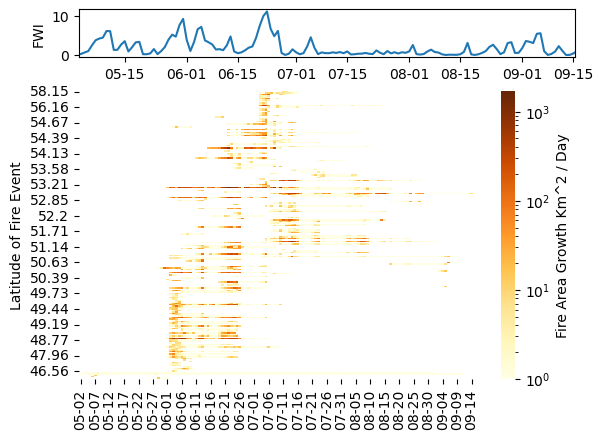

In [15]:


fig, (ax, ax2) = plt.subplots(2, gridspec_kw={'height_ratios': [1, 6]})
#fig.suptitle('Aligning x-axis using sharex')
ax2 = sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, fmt='.1f')#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
ax.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
ax.set_ylabel("FWI")
#plt.savefig(f"Regional_fire_growth_FWI_{datetime.today().strftime('%Y%m%d')}.png")

In [16]:
dates = no_dupes['t'].astype('datetime64[ns]')
dates = dates.drop_duplicates()
# print(len(dates.dt.strftime('%-m-%-d')))
# print(len(heat.columns))

In [17]:
### New Color bar

from matplotlib.colors import LinearSegmentedColormap

# Retrieve the original colormap
original_cmap = plt.get_cmap('YlOrBr')



def create_darker_colormap(base_cmap_name, darkness_factor):
    """
    Create a darker version of a given colormap.
    
    Parameters:
    - base_cmap_name: str, the name of the base colormap.
    - darkness_factor: float, a factor between 0 and 1 to darken the colormap.
                       1 means no change, 0 means completely dark.
    
    Returns:
    - LinearSegmentedColormap: a new colormap that is a darker version of the base colormap.
    """
    # Retrieve the original colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    
    # Create a list of colors from the colormap and darken them
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[:, :3] *= darkness_factor
    colors = np.clip(colors, 0, 1)  # Ensure values are within [0, 1]
    
    # Create the new colormap
    return LinearSegmentedColormap.from_list(f"{base_cmap_name}_darker", colors)

# Define the darkness factor (between 0 and 1)
darkness_factor = 0.85

# Create a custom colormap with the specified darkness factor
darker_cmap = create_darker_colormap('YlOrBr', darkness_factor)

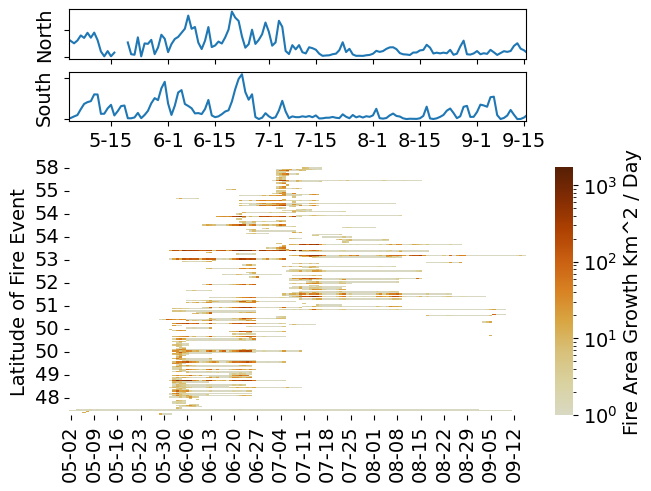

In [18]:

#from matplotlib.ticker import IndexFormatter
# fig, ax  = plt.subplots(2, 2, sharex='col', gridspec_kw={'width_ratios':[100,5]})
# ax[0,1].remove()  # remove unused upper right axes
# ax[0,0].plot(x+0.5,L_1,'-', marker='o',color='tab:orange')
# sn.heatmap(M_1, cmap=cmap, vmax=np.max(M_1), center=np.max(M_1)/2., square=False, ax=ax[1,0], cbar_ax=ax[1,1])

def quick_round(x, pos=None):
    x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)

def quick_round2(x, pos = None, obj = heat):
    x = int(x)
    #print(x)
    x = obj.index[x]
    #x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)


def quick_round3(x, pos = None, obj = heat):
    x = int(x)
    index = obj.index[x]
    #x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)
    
#plt.style.use('dark_background')
with mpl.rc_context({'font.size': 14}):
    fig, ([ax, ax2], [ax3, ax4], [ax5, ax6]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,1, 5]}, constrained_layout=True)
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
    ax.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
    ax.set_ylabel("North")
    ax.set_xticklabels("")
    ax.set_yticklabels("")


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
    ax3.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
    ax3.set_ylabel("South")
    ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(heat, cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))

    #ax5.yaxis.set_major_formatter(StrMethodFormatter('{x:,f}'))
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round))
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #fmtr = mpl.ticker.FuncFormatter(heat.index.round(0))
   
    ax2.remove()
    ax4.remove()

    #plt.gcf().subplots_adjust(bottom=0.15)
    #plt.tight_layout()
    #plt.show()
    #plt.savefig('darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)
    #plt.savefig('low_rez_darker_Regional_fire_growth_FWI.png', dpi = 100, transparent = False)
    #plt.savefig(f"/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [19]:
example = no_dupes[(no_dupes.lat_centroid <= 58.00) & (no_dupes.lat_centroid >= 54.86)].pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values="farea_diff")

In [20]:
def make_heat_map(path, piv_values, crs, start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', round_var = True):
    '''
    path (str): 
    piv_values (str):
    
    '''
    sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
    import fwiVis.fwiVis as fvs
    ## Read in 
    fires = fvs.prep_fire_files(path, crs = crs)
    #print(fires.crs)
    #fires = gpd.read_file(path)
    
    fires = fires.to_crs("EPSG:4326")
    fires = fires.sort_values(by = ["fireID", "t"])
    fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"
    #return(fires)
    fires = fires[~fires.geometry.isna()]
    fires = fires.drop_duplicates()

    ## subset by start and end time
    fires = fires[fires.t >= start_time]
    fires = fires[fires.t <= end_time]

    # ## Subset to the province of quebec
    # prov = fv.ca_prov()
    # prov = prov[prov.prov_name_en == "Quebec"]
    # prov = prov.to_crs('EPSG:3571')
    # fires = fires.to_crs('EPSG:3571')
    # fires = fires.sjoin(prov)
    # fires = fires.drop(['prov_name_fr', 'prov_name_en', 'index_right'], axis = 1)
    # fires = fires[~fire3.geometry.isna()]
    # fires = fires.to_crs("EPSG:4326")
    #print(f"Number of fireID in fires object {len(fires.fireID.unique())}")
    
    ## Merge with CIFFC
    fires.t = pd.to_datetime(fires.t, format='ISO8601')
    #return(fires)
    #fires = fires.sjoin(ciffc.to_crs("4326"))

    ## Merge with NBAC
    nbac_only = gpd.read_file(f"{os.path.abspath('contextual_data')}/NBAC/nbac_2023_20240530.shp")
    nbac_only = nbac_only[nbac_only.ADMIN_AREA == 'QC']
    nbac_only  = nbac_only [(nbac_only.ADJ_HA >= 400) |(nbac_only.POLY_HA >= 400)]
    nbac_only = nbac_only[(nbac_only.HS_SDATE <= "2023-09-15" ) |  (nbac_only.AG_SDATE <= "2023-09-15")]
    fires = fires.to_crs(nbac_only.crs)
    fires = fires.sjoin(nbac_only)
   #  fires = fires.drop(['YEAR', 'NFIREID', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
   # 'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
   # 'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
   # 'GID'], axis=1)
    fires = fires.drop(['YEAR', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
   'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
   'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
   'GID'], axis=1)
    fires = fires.to_crs("4326")
    
    #fires = average_var_from_multiple_fires(fires)
    fires.farea = fires.farea.astype("int64")

    #fires = fvs.formatting_read_in(path)

    ## Make the dataes into a nicer format
    fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d %p")
    fires = fires[fires.pretty_date_format.str.contains("PM")] ## Make  only noon to noon comparisons
    fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d")
    print(f"Number of fireID in fires object {len(fires.fireID.unique())}")

    ### Cacluate number for plot
    #fires["farea_diff"] = fires.groupby("fireID").farea.diff()
    
    fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
    fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=True) ## get lat centroids for later use
    print(f"Number of fireID in fires object {len(fires.fireID.unique())}")

    ### Make a new datarame with no duplicates
    no_dupes = fires[["fireID", "pretty_date_format", "farea_diff", "lat_centroid", "t", "FWI"]]
    no_dupes = no_dupes.dropna()
    no_dupes = no_dupes.drop_duplicates(subset = ["fireID", "t"])
    no_dupes["log_difference"] = np.log(no_dupes.farea_diff)
    print(f"Number of fireID in no dupes object {len(no_dupes.fireID.unique())}")


    ### Find mean lat so that the lattitide axis is prettier
    lats = no_dupes[['fireID', 'pretty_date_format', 'farea_diff', 'lat_centroid', 't',
           'log_difference', "FWI"]].groupby("fireID").lat_centroid.mean().reset_index()
    no_dupes = no_dupes[['fireID','pretty_date_format', 'farea_diff', 'log_difference', 't', "FWI"]].reset_index().merge(lats, on = ["fireID"])

    ## Change values so they don't get set as NA on a log scale

    no_dupes["farea_diff_mod"] = no_dupes.farea_diff + 1 # Account for log. Minimum = 1. 
    no_dupes.loc[(no_dupes.farea_diff_mod < 0), ["farea_diff_mod"]] = 1

    print("modifying values to fit log color scale: 0 -> 1, nagative number -> 1")
    print(f"Number of fireID in no dupes object {len(no_dupes.fireID.unique())}")


    ### Put into pivot table
    
    heat = no_dupes.pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values= piv_values)
    print(f"Number of fireID in heat object {len(heat)}")

    heat = heat.sort_values(by = "lat_centroid", ascending= False)
    heat.index = heat.index.astype("float64")
    if(round_var):
        heat.index = heat.index.values.round(2)
    print(f"Number of fireID in heat object {len(heat)}")

    return([heat, no_dupes])
    

In [21]:
#test_func = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_06172024.csv", "farea_diff_mod", crs = "3571")
path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire_test = fv.prep_fire_files(path)
test_func = make_heat_map(path, "farea_diff_mod", crs = "3571")

/tmp/ipykernel_699/3719089673.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"


Number of fireID in fires object 160


/tmp/ipykernel_699/3719089673.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
/tmp/ipykernel_699/3314272417.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tmp["farea_unitless"] = df_tmp.geometry.area
/tmp/ipykernel_699/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/tmp/ipyke

Number of fireID in fires object 160
Number of fireID in no dupes object 160
modifying values to fit log color scale: 0 -> 1, nagative number -> 1
Number of fireID in no dupes object 160
Number of fireID in heat object 160
Number of fireID in heat object 160


/tmp/ipykernel_699/3314272417.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lon = df_tmp[df_tmp.farea_unitless == max_u].centroid.x
/tmp/ipykernel_699/3314272417.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tmp["farea_unitless"] = df_tmp.geometry.area
/tmp/ipykernel_699/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/tmp/ipykernel_699/3314272417.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometri

In [22]:


zones = gpd.read_file(f"{os.path.abspath('contextual_data')}/supression_zones_quebec/Full_response_limit.shp")
zones= zones.set_crs(32198)

zones = zones.to_crs("4326")
zones['geometry'] = shapely.unary_union(zones.geometry)

def get_mid_line(bounds):
    mid_x = (bounds[0] + bounds[2])/2
    mid_y = (bounds[1] + bounds[3])/2
    mid_line = shapely.LineString([[bounds[0], mid_y], [mid_x, mid_y], [bounds[2], mid_y]])
    return(mid_line)

zones_avg_line = zones.copy()
zones_avg_line['geometry'] = get_mid_line(zones.geometry[0].bounds)


# def get_mid_line(bounds):
#     mid_x = (bounds[0] + bounds[2])/2
#     mid_y = (bounds[1] + bounds[3])/2
#     mid_line = shapely.LineString([[bounds[0], mid_y], [mid_x, mid_y], [bounds[2], mid_y]])
#     return(mid_line)


# zones_avg_line = zones.copy()
# zones_avg_line['geometry'] = get_mid_line(zones.geometry[0].bounds)

In [23]:
# print(test_func2[1].lat_centroid.min())
# print(test_func2[1].lat_centroid.max())

# print(test_func[1].lat_centroid.min())
# print(test_func[1].lat_centroid.max())

## Figure 1 heatmap

In [24]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_MEAN.csv')

FWI_data_south_75 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_75.csv')
FWI_data_south_25 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_25.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_MEAN.csv')
FWI_data_north_75 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_75.csv')
FWI_data_north_25 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_25.csv')

Dates range from 2023-05-31 12:00:00  to 2023-09-15 12:00:00
after plotting:
ax xlim: (np.float64(19508.5), np.float64(19615.5))
ax3 xlim: (np.float64(19508.5), np.float64(19615.5))
after plotting all three:
ax5 xlim: (np.float64(19508.5), np.float64(19615.5))
ax7 xlim: (np.float64(19508.5), np.float64(19615.5))
ax9 xlim: (np.float64(0.0), np.float64(108.0))
Average supression boundary is 51.15011188704433 
Text(0, 0.5, '58.15')
58
Text(0, 12.5, '55.11')

Text(0, 24.5, '54.5')

Text(0, 36.5, '54.2')

Text(0, 48.5, '53.57')

Text(0, 60.5, '53.03')

Text(0, 72.5, '52.07')

Text(0, 84.5, '51.34')
51
Text(0, 96.5, '50.72')

Text(0, 108.5, '50.39')

Text(0, 120.5, '49.7')

Text(0, 132.5, '49.35')

Text(0, 144.5, '48.98')

Text(0, 156.5, '47.98')
48
before sharing:
ax xlim: (np.float64(19508.5), np.float64(19615.5))
ax3 xlim: (np.float64(19508.5), np.float64(19615.5))
ax5 xlim: (np.float64(0.0), np.float64(108.0))
after sharing:
ax xlim: (np.float64(0.0), np.float64(108.0))
ax3 xlim: (np.flo

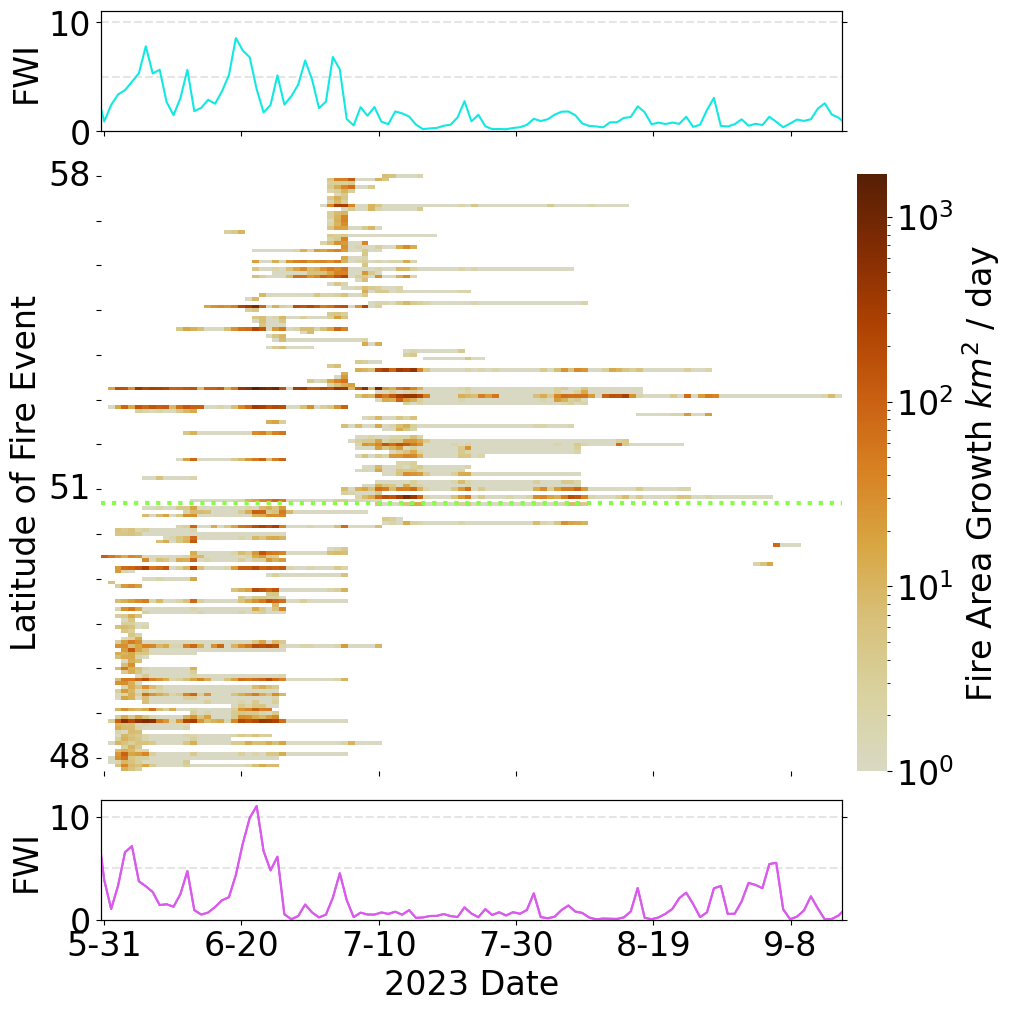

In [25]:
# def current_tick_modify(ax, desired_value):
#     current_ticks = list(ax.get_yticks())
#     if desired_value not in current_ticks:
#         current_ticks.append(desired_value)
#         current_ticks.sort()
#     ax.set_yticks(current_ticks)

import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

# def current_tick_modify(ax, desired_value, max_ticks=4):
#     """Add a tick while maintaining good spacing"""
#     ylim = ax.get_ylim()
    
#     # Generate a reasonable number of ticks across the range
#     auto_ticks = np.linspace(ylim[0], ylim[1], max_ticks)
    
#     # Add your desired value
#     all_ticks = np.append(auto_ticks, desired_value)
    
#     # Remove duplicates and sort
#     all_ticks = np.unique(all_ticks)
    
#     # Only keep ticks within the y-limits
#     all_ticks = all_ticks[(all_ticks >= ylim[0]) & (all_ticks <= ylim[1])]
    
#     ax.yaxis.set_major_locator(ticker.FixedLocator(all_ticks))

# def current_tick_modify(ax, desired_value):
#     current_ticks = ax.get_yticks()
#     all_ticks = np.append(current_ticks, desired_value)
#     all_ticks = np.unique(all_ticks)
    
#     # Use FixedLocator to set the final ticks
#     ax.yaxis.set_major_locator(ticker.FixedLocator(all_ticks))

def only_min_max_mid(x, pos=None):
    x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)


def interpolate_position(target_value, values, positions):
    """Get interpolated position for a target value"""
    # Create interpolation function (values to positions)
    # Note: values are in descending order, so we need to handle this
    interp_func = interp1d(values[::-1], positions[::-1], 
                          bounds_error=False, fill_value='extrapolate')
    
    return interp_func(target_value)

font_size = 24 
with mpl.rc_context({'font.size': font_size}):
    fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]},figsize=(10, 10),constrained_layout=True)
    #fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4], [ax6, ax7]) = plt.subplots(4,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1, 1]}, constrained_layout=True)
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5, color = "#12e8e2")
    ax.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    print(f"Dates range from {test_func[1].t.min()}  to {test_func[1].t.max()}")
    ax.set_ylim(bottom = 0)
    #ax.set_ylim(top = 15)
    #ax.set_ylabel("NPZ") #  \n FWI"
    ax.set_ylabel("FWI") #  \n FWI"
    # ax.set_xticklabels("")
    ax.tick_params(axis='x', labelbottom=False)
    #ax.set_yticklabels("")
    #ax.set_yticklabels("")
    #ax.set_yticks([])
    
    desired_ticks = [0, 10]
    # Combine and remove duplicates
    #all_ticks = list(current_ticks) + desired_ticks
    #all_ticks = sorted(list(set(all_ticks)))
    all_ticks1 = sorted(list(set(desired_ticks)))
    ax.set_ylim(top = 11)
    ax1 = ax.twinx()
    ### LINES
    #current_tick_modify(ax1, 15)
    # ax1.axhline(y = 15, linestyle = "dashed", alpha = 0.5,  color = "gray")
    ax1.axhline(y = 10, linestyle = "dashed", alpha = 0.2,  color = "gray")
    ax1.axhline(y = 5, linestyle = "dashed", alpha = 0.2, color = "gray")
    ax1.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5, color = "#12e8e2")
    #ax11 = ax.twinx()
    #ax11.fill_between(FWI_data_north_75.INITDATE.astype("datetime64[ns]"), FWI_data_north_75['GEOS-5.IMERGEARLY'], FWI_data_north_25['GEOS-5.IMERGEARLY'], color = "#12e8e2",  alpha = 0.2)
    #ax1.set_ylim(bottom = 0)
    ax1.set_yticklabels("")
    ax1.set_yticks([])
    ax1.set_ylim(top = 11)
    #ax1.tick_params(axis='y', labelsize=font_size)
    y_min1, y_max1 = ax.get_ylim()
    filtered_ticks1 = [tick1 for tick1 in all_ticks1 if y_min1 <= tick1 <= y_max1]
    ax1.set_ylim(bottom = y_min1)
    ax1.set_yticks(filtered_ticks1)

    #ax1.yaxis.set_label_position('left')
    #ax1.set_ylabel("FWI", loc = 'center')
    #ax1.set_ylabel("", loc = 'center')
    #ax1.tick_params(axis='y', which='major', labelsize=font_size - 3)
    #ax1.set_yticklabels("")
    #ax1.set_yticks([])

 

    # # ## Tick nonesense 
    # #current_ticks = ax1.get_yticks()
    desired_ticks = [0, 10]
    # Combine and remove duplicates
    #all_ticks = list(current_ticks) + desired_ticks
    #all_ticks = sorted(list(set(all_ticks)))
    all_ticks = sorted(list(set(desired_ticks)))
    # Filter to keep only ticks within a reasonable range
    # y_min, y_max = ax31.get_ylim()
    # filtered_ticks = [tick for tick in all_ticks if y_min <= tick <= y_max]
    # print(filtered_ticks)
    # ax31.set_yticks(filtered_ticks)


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.set_xlabel("2023 Date")
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5, color = "#d85beb")
    ax3.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax3.set_ylim(bottom = 0)
    #ax3.set_ylim(top = 15)
    #ax3.set_ylabel("IPZ")
    ax3.set_ylabel("FWI")
    #ax3.set_yticklabels("")
    #ax3.set_yticks([])

    ax31 = ax3.twinx()
    ax31.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5, color = "#d85beb")
    ax31.set_ylim(bottom = 0)
    ax31.set_yticklabels("")
    ax31.set_yticks([])
    #ax31.set_ylabel("FWI", loc = 'center')
    ax31.set_ylabel("", loc = 'center')
    ### LINES
    # ax31.axhline(y = 15, linestyle = "dashed", alpha = 0.5,  color = "gray")
    ax31.axhline(y = 10, linestyle = "dashed", alpha = 0.2,  color = "gray")
    ax31.axhline(y = 5, linestyle = "dashed", alpha = 0.2, color = "gray")
    ax31.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5, color = "#d85beb")
    #ax31.tick_params(axis='y', which='major', labelsize=font_size - 3)
    #ax311 = ax3.twinx()
    #ax311.fill_between(FWI_data_south_75.INITDATE.astype("datetime64[ns]"), FWI_data_south_75['GEOS-5.IMERGEARLY'], FWI_data_south_25['GEOS-5.IMERGEARLY'], color = "#d85beb",  alpha = 0.2)
    y_min, y_max = ax31.get_ylim()
    filtered_ticks = [tick for tick in all_ticks if y_min <= tick <= y_max]
    ax31.set_yticks(filtered_ticks)
    
    print("after plotting:")
    print(f"ax xlim: {ax.get_xlim()}")
    print(f"ax3 xlim: {ax3.get_xlim()}")


    #ax5 = plt.subplot( sharex=ax1)
   
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth $km^2$ / day'}, ax = ax5, cbar_ax=ax6, square=False, xticklabels = 20)#,fmt='.1f', 
    average_suppressionBoundary = (zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2

    print("after plotting all three:")
    print(f"ax5 xlim: {ax.get_xlim()}")
    print(f"ax7 xlim: {ax3.get_xlim()}")
    print(f"ax9 xlim: {ax5.get_xlim()}")
    
    print(f"Average supression boundary is {average_suppressionBoundary} ")
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2)) ### Causes anindexing error but "Should" work

    ## Rounding Labs and setting where midline is proportinally to where labels are
    labs = ax5.get_yticklabels()
    foo = zones_avg_line.geometry.iloc[0].coords.xy
    target_value = foo[1][1] #zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2
    interpolated_pos = interpolate_position(
    target_value, 
    [float(obj.get_text()) for obj in labs],
    [obj.get_position()[1] for obj in labs]
    )
    
    ax5.axhline(y = interpolated_pos, color = "#86fd45", linestyle = "dotted", linewidth=3)


    ts = []
    for lb in labs:
        t = lb.get_text()
        ts.append(t)
    ts_diff = [float(x) - target_value for x in ts]
    new_df = pd.DataFrame({'diff_num': ts_diff, 'y_val': ts})
    new_df.diff_num = new_df.diff_num * new_df.diff_num ### Squaring to get rid of annoying negative values
    mid_val = new_df[new_df.diff_num == new_df.diff_num.min()].y_val.iloc[0]
    
    labs_fix = []
    for l in labs:
        #txt = quick_round(l.get_text())
        txt = l.get_text()
        if((txt == mid_val) | (txt == max(ts)) | (txt == min(ts))):
            snp = txt
            snp = round(float(snp))
        else:
            snp = ''
        print(l)
        print(snp)
        #labs_fix.append(txt)
        labs_fix.append(snp)
    ax5.set_yticklabels(labs_fix)

    ax5.xaxis.set_ticklabels([pd.to_datetime(value, format = '%m-%d').strftime('%-m-%-d') for value in ax5.xaxis.get_major_formatter().func.args[0].values()])
    print("before sharing:")
    print(f"ax xlim: {ax.get_xlim()}")
    print(f"ax3 xlim: {ax3.get_xlim()}")
    print(f"ax5 xlim: {ax5.get_xlim()}")
    ax.sharex(ax5)
    ax3.sharex(ax5)

    print("after sharing:")
    print(f"ax xlim: {ax.get_xlim()}")
    print(f"ax3 xlim: {ax3.get_xlim()}")
    print(f"ax5 xlim: {ax5.get_xlim()}")
  
    
    #ax5.axhline(y = (zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2, color = "#777777", linestyle = "dotted")
    #print((zones.geometry[0].bounds[1] + zones.geometry[0].bounds[3])/2)
    
    #ax5.axes.get_xaxis().set_visible(False)
    ax5.tick_params(axis='x', labelbottom=False)
    #ax5.axes.get_yaxis().set_visible(False)

    #ax5.set_yticks([])
    #ax5.tick_params(left=False, labelleft=False)
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    #ax3.get_shared_x_axes().join(ax1, ax3, ax5)
    
    #zones_avg_line.plot(ax= ax5, color = "#86fd45", linestyles='dotted', linewidths = 2)
    
    
    
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax6.plot()
    ax2.remove()
    ax4.remove()
    #ax7.remove()
    #plt.show()
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2)) ### Causes anindexing error but "Should" work
    plt.savefig(f"some_figs/low_rez_darker_Regional_fire_growth_FWI_with_line_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)
    plt.show()

In [26]:
remerged = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)

In [27]:
#get_fwi = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_06172024.csv", "FWI")
#get_fwi = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_plus_area_fix_09042024.csv", "FWI", crs =  4326)
get_fwi = make_heat_map(os.path.abspath(f'data/Quebec_v3_full_data_perimeters20241112.csv'), "FWI", crs =  3571)

/tmp/ipykernel_699/3719089673.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"


Number of fireID in fires object 160


/tmp/ipykernel_699/3719089673.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
/tmp/ipykernel_699/3314272417.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tmp["farea_unitless"] = df_tmp.geometry.area
/tmp/ipykernel_699/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/tmp/ipyke

Number of fireID in fires object 160
Number of fireID in no dupes object 160
modifying values to fit log color scale: 0 -> 1, nagative number -> 1
Number of fireID in no dupes object 160
Number of fireID in heat object 160
Number of fireID in heat object 160


/tmp/ipykernel_699/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/tmp/ipykernel_699/3314272417.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lon = df_tmp[df_tmp.farea_unitless == max_u].centroid.x
/tmp/ipykernel_699/3719089673.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=

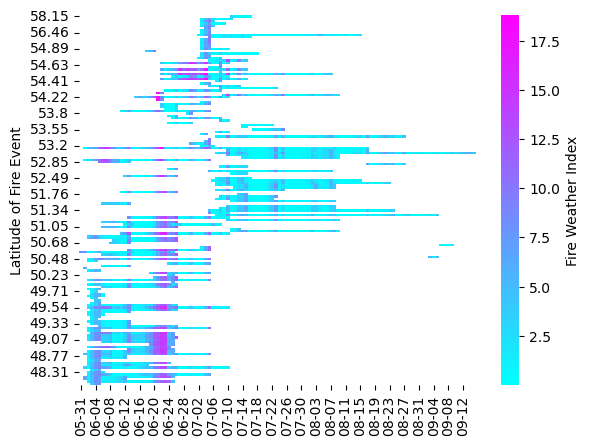

In [28]:
fig2, (ax2) = plt.subplots(1)
#fig.suptitle('Aligning x-axis using sharex')
ax2 = sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, fmt='.1f')#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")
#ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))


#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
#ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#ax.set_xlim(get_fwi[1].t.astype("datetime64[ns]").min(), get_fwi[1].t.astype("datetime64[ns]").max())
#ax.set_ylabel("FWI")

#plt.savefig('FWI_for_darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)

plt.savefig(f"some_figs/FWI_for_darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [29]:





with_labels = make_heat_map(os.path.abspath(f'data/Quebec_v3_full_data_perimeters20241112.csv'), "FWI", crs =  3571, round_var = False)

/tmp/ipykernel_699/3719089673.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"


Number of fireID in fires object 160


/tmp/ipykernel_699/3719089673.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
/tmp/ipykernel_699/3314272417.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tmp["farea_unitless"] = df_tmp.geometry.area
/tmp/ipykernel_699/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/tmp/ipyke

Number of fireID in fires object 160
Number of fireID in no dupes object 160
modifying values to fit log color scale: 0 -> 1, nagative number -> 1
Number of fireID in no dupes object 160
Number of fireID in heat object 160
Number of fireID in heat object 160


In [30]:
with_labels[0].loc[:, "fireID"] = np.nan

for i in with_labels[0].index:
    fireID = with_labels[1][with_labels[1]["lat_centroid"] == i].fireID.unique()
    #print(fireID)

    if(len(fireID) > 1):
        print(f" Unexpected number of fireIDs {fireID}")
    #fireID = fireID[0]

    with_labels[0].loc[with_labels[0].index == i, "fireID"] = fireID

with_labels[0].to_csv(f"FWI_for_darker_Regional_fire_growth_FWI_diff_fix_no_rounding_{datetime.today().strftime('%Y%m%d')}.csv", index = False)
    

/tmp/ipykernel_699/695746578.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['3025']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  with_labels[0].loc[with_labels[0].index == i, "fireID"] = fireID


In [31]:
remerged.columns

Index(['fireID', 't', 'geometry', 'Unnamed: 0', 'mergeid', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't_st', 't_ed', 'isignition', 't_inactive', 'isactive',
       'isdead', 'mayreactivate', 'geom_counts', 'low_confidence_grouping',
       'region', 'primarykey', 'csv_geometry', 'GEOS-5.IMERGEARLY', 'FWI',
       'FWI_lead_1', 'FWI_lead_2', 'FWI_lead_3', 'FWI_lead_4', 'FWI_lead_5',
       'FWI_lead_6', 'FWI_lead_7', 'FWI_lead_8'],
      dtype='object')

In [32]:
## Make a companion figure that shows # of fires growing to a specific threshold per day

grow_day = test_func[1]

def get_num_fires(df):
    n = len(df.fireID.unique())
    return(n)


will_grow = 6.91
num_fires = grow_day[grow_day.farea_diff > 20].groupby("t").apply(get_num_fires).reset_index()

fire3 = fire3[~fire3.FWI.isna()]
fire_calc_num_fr = fire3

fire3_match = fv.formatting_read_in(path = 'data/Quebec_v3_full_data_perimeters20241112.csv')


num_fr = pd.DataFrame(None, index=range(0, len(fire3_match.t.unique())), columns=["Num_fire_spreading_1km2", "Num_fire_over_thresh", "t", "total_fires"])
for i,t in enumerate(fire3_match.t.unique()):
    #print(i)
    fr_t = fire3_match[fire3_match.t == t]
    fr_t.loc[fr_t.is_ig, ["farea_diff_stand"]] = fr_t.loc[fr_t.is_ig, ["farea"]].to_numpy()
    num_fr.loc[i, "t"] = t
    num_fr.loc[i, "Num_fire_spreading_1km2"] = len(fr_t[fr_t.farea_diff_stand >= 1].fireID.unique())
    num_fr.loc[i, "Num_fire_over_thresh"] = len(fr_t[fr_t['GEOS-5.IMERGEARLY'] >= will_grow].fireID.unique())
    num_fr.loc[i, "total_fires"] = len(fr_t.fireID.unique())


#num_fires

/tmp/ipykernel_699/2986499850.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num_fires = grow_day[grow_day.farea_diff > 20].groupby("t").apply(get_num_fires).reset_index()
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)
/srv/conda/envs/notebook/lib/python3.1

In [33]:
sum_growth = grow_day[grow_day.farea_diff >= 0].groupby("t").farea_diff.sum().reset_index()
#ig_growth = grow_day[grow_day.farea_diff.isna()].groupby("t").farea.rest_index()

grow_day

,index,fireID,pretty_date_format,farea_diff,log_difference,t,FWI,lat_centroid,farea_diff_mod
0,0,1003,06-08,6.0,1.791759,2023-06-08 12:00:00,4.459401,50.680789,7.0
1,1,1003,06-09,12.0,2.484907,2023-06-09 12:00:00,3.740743,50.680789,13.0
2,2,1003,06-10,0.0,-inf,2023-06-10 12:00:00,2.280053,50.680789,1.0
3,3,1003,06-11,4.0,1.386294,2023-06-11 12:00:00,0.453373,50.680789,5.0
4,4,1003,06-12,10.0,2.302585,2023-06-12 12:00:00,1.262629,50.680789,11.0
...,...,...,...,...,...,...,...,...,...
2524,2529,891,06-22,0.0,-inf,2023-06-22 12:00:00,9.373624,51.158267,1.0
2525,2530,891,06-23,7.0,1.945910,2023-06-23 12:00:00,11.930853,51.158267,8.0
2526,2531,891,06-24,10.0,2.302585,2023-06-24 12:00:00,7.970543,51.158267,11.0
2527,2532,891,06-25,4.0,1.386294,2023-06-25 12:00:00,9.182748,51.158267,5.0


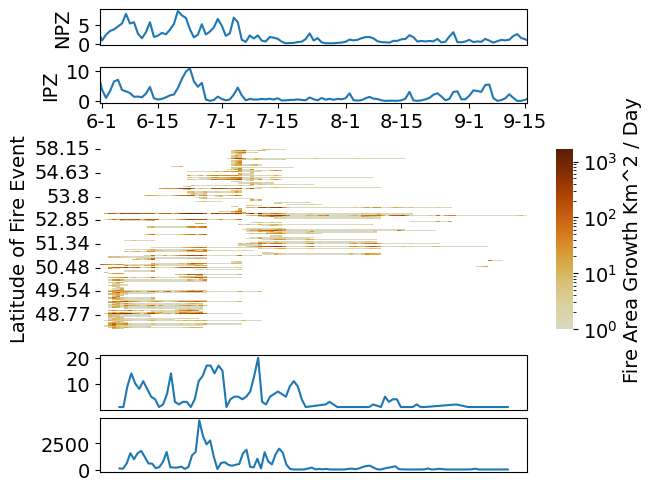

In [34]:
with mpl.rc_context({'font.size': 14}):
    fig1, ([ax, ax2], [ax3, ax4], [ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(5,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [2,2, 10, 3, 3]}, constrained_layout=True)#constrained_layout=True
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
    ax.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax.set_ylabel("NPZ")
    #ax.set_xticklabels("")
    ax.axes.get_xaxis().set_visible(False)
    #ax.set_yticklabels("")


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
    ax3.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax3.set_ylabel("IPZ")
    #ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.axes.get_xaxis().set_visible(False)
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
    #ax5.set_xticklabels("")
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax7.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax7.axes.get_xaxis().set_visible(False)
    ax7.plot(num_fires.t, num_fires.iloc[:, 1:])
    ax7.set_ylabel("") # # >= 20
    
    ax9.axes.get_xaxis().set_visible(False)
    ax9.plot(sum_growth.t, sum_growth.iloc[:, 1:])
    ax9.set_ylabel("") # Total km
   
    ax2.remove()
    ax4.remove()
    ax8.remove()
    ax10.remove()
    
    plt.savefig(f"some_figs/Number_of_fires_growing_over_20km2_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

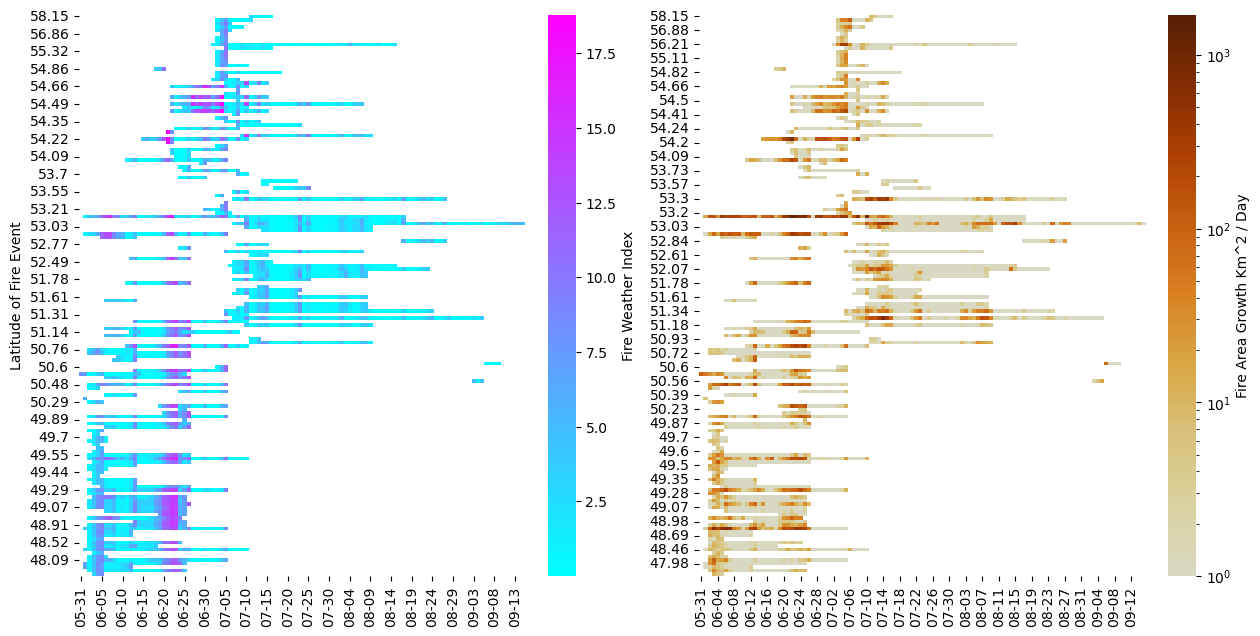

In [35]:
fig2, ([ax2, ax3]) = plt.subplots(1,2, figsize = (12.5, 6.25), gridspec_kw={'width_ratios': [2,2], 'height_ratios': [1]}, constrained_layout=True)
#fig.suptitle('Aligning x-axis using sharex')
sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, ax = ax2, fmt='.1f', square = False)#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")
#ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))

sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax3, square = False)#,fmt='.1f', 
#ax3.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
ax3.set(xlabel="", ylabel="")
#ax3.axes.get_xaxis().set_visible(False)


#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
#ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#ax.set_xlim(get_fwi[1].t.astype("datetime64[ns]").min(), get_fwi[1].t.astype("datetime64[ns]").max())
#ax.set_ylabel("FWI")

#plt.savefig('FWI_for_darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)

plt.savefig(f"some_figs/Both_FWI_for_darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [36]:
# with mpl.rc_context({'font.size': 14}):
#     fig1, ([ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [30, 7, 7]}, constrained_layout=True)#constrained_layout=True
#     #fig.suptitle('Aligning x-axis using sharex')

#     #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# #     ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
# #     ax.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
# #     ax.set_ylabel("North")
# #     #ax.set_xticklabels("")
# #     ax.axes.get_xaxis().set_visible(False)
# #     #ax.set_yticklabels("")


# #     ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
# #     ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
# #     ax3.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
# #     ax3.set_ylabel("South")
# #     #ax3.set_yticklabels("")



#     #ax3 = 
#     #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
#     sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
#     ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    
#     #ax5.axes.get_xaxis().set_visible(False)
    
#     #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
#     labs = ax5.get_yticklabels()
#     labs_fix = []
#     for l in labs:
#         txt = quick_round(l.get_text())
#         labs_fix.append(txt)
#     ax5.set_yticklabels(labs_fix)
#     #ax5.set_xticklabels("")
#     #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
#     #ax7.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
#     ax7.axes.get_xaxis().set_visible(False)
#     ax7.plot(num_fires.t, num_fires.iloc[:, 1:])
#     #ax7.set_ylabel("# > 20") # # >= 20
#     ax7.set_title("# Fires >= 20km^2 Growth")
    
#     #ax9.axes.get_xaxis().set_visible(False)
#     ax9.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
#     ax9.plot(sum_growth.t, sum_growth.iloc[:, 1:])
#     ax9.set_title("Total Area Growth km^2")
#     #ax9.set_ylabel("Sum Growth", rotation=0) # Total km
   
#     #ax2.remove()
#     #ax4.remove()
#     ax8.remove()
#     ax10.remove()
    
#     plt.savefig(f"some_figs/Number_of_fires_growing_over_20km2_Regional_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [37]:
num_fr.t = num_fr.t.astype("datetime64[ns]")
num_fr = num_fr.sort_values(by = "t")
num_fr = num_fr[num_fr.t >= "2023-05-31 00:00:00"]
num_fr = num_fr[num_fr.t <= "2023-09-15 12:00:00"]

num_fr.loc[:, "t2"] = num_fr.t.dt.strftime("%Y-%d-%m")
sum_growth.loc[:, "t2"] = sum_growth.t.dt.strftime("%Y-%d-%m")
num_fr['t_date_only'] = num_fr.t.dt.date
sum_growth['t_date_only'] = sum_growth.t.dt.date

num_fr_converted = num_fr.copy()
sum_growth_converted = sum_growth.copy()

# Convert to date-only strings or date objects (like fwin.INITDATE)
num_fr_converted['t'] = pd.to_datetime(num_fr.t.dt.date)  # Remove time component
sum_growth_converted['t'] = pd.to_datetime(sum_growth.t.dt.date)

In [38]:
# import numpy as np
# import matplotlib.pyplot as plt

# def r_squared_against_1to1_line(y_true, y_pred):
#     """
#     Calculate R² (coefficient of determination) against a 1:1 line.
    
#     This measures how well the data fits the perfect agreement line (1:1 line)
#     rather than against a best-fit regression line.
    
#     Parameters:
#     -----------
#     y_true : array-like
#         Ground truth (correct) values
#     y_pred : array-like
#         Predicted or test values to compare
        
#     Returns:
#     --------
#     r_squared : float
#         R² value against the 1:1 line. Values closer to 1 indicate better agreement.
#         Can be negative if predictions are worse than using the mean as a predictor.
#     """
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)
    
#     # Total sum of squares (proportional to variance of the data)
#     ss_tot = np.sum((y_true - np.mean(y_true))**2)
    
#     # Sum of squares of residuals from 1:1 line
#     # For 1:1 line, the predicted value should equal the true value
#     ss_res = np.sum((y_true - y_pred)**2)
    
#     # R² calculation
#     r_squared = 1 - (ss_res / ss_tot)
    
#     return r_squared

# r_sq = r_squared_against_1to1_line(num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh)



# plt.scatter( num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh)

# maxnum = max(num_fr.Num_fire_spreading_1km2.max(), num_fr.Num_fire_over_thresh.max())
# #minnum = min([num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh])
# plt.plot(range(0,maxnum ), range(0,maxnum))
# plt.title(f"Timeseries Predicted Vs Observed {r_sq}")
# plt.xlabel("Observed # of Fires")
# plt.ylabel("Predicted # of Fires")
# plt.show()



# ## Calculating the first dirivative to get at "Timing" 
# y_deriv_observed = np.gradient(num_fr.Num_fire_spreading_1km2 )
# y_deriv_predicted = np.gradient(num_fr.Num_fire_over_thresh )

# r_sq_deriv = r_squared_against_1to1_line(y_deriv_observed, y_deriv_predicted)


# plt.scatter( y_deriv_observed, y_deriv_predicted)
# #plt.plot(range(0, (y_deriv_observed.max()) ), range(0, np.ceiling(y_deriv_observed.max())))
# plt.title(f"First Derivative R^2: {r_sq_deriv}")
# plt.xlabel("Observed # of Fires")
# plt.ylabel("Predicted # of Fires")
# plt.show()

# plt.plot(num_fr.t, y_deriv_observed )
# plt.plot(num_fr.t,  y_deriv_predicted )

Average suppression boundary is 51.15011188704433
After setting up datetime coordinates:
ax5 xlim: (np.float64(19508.5), np.float64(19615.5))
ax7 xlim: (np.float64(19508.5), np.float64(19615.5))
ax9 xlim: (np.float64(19508.5), np.float64(19615.5))


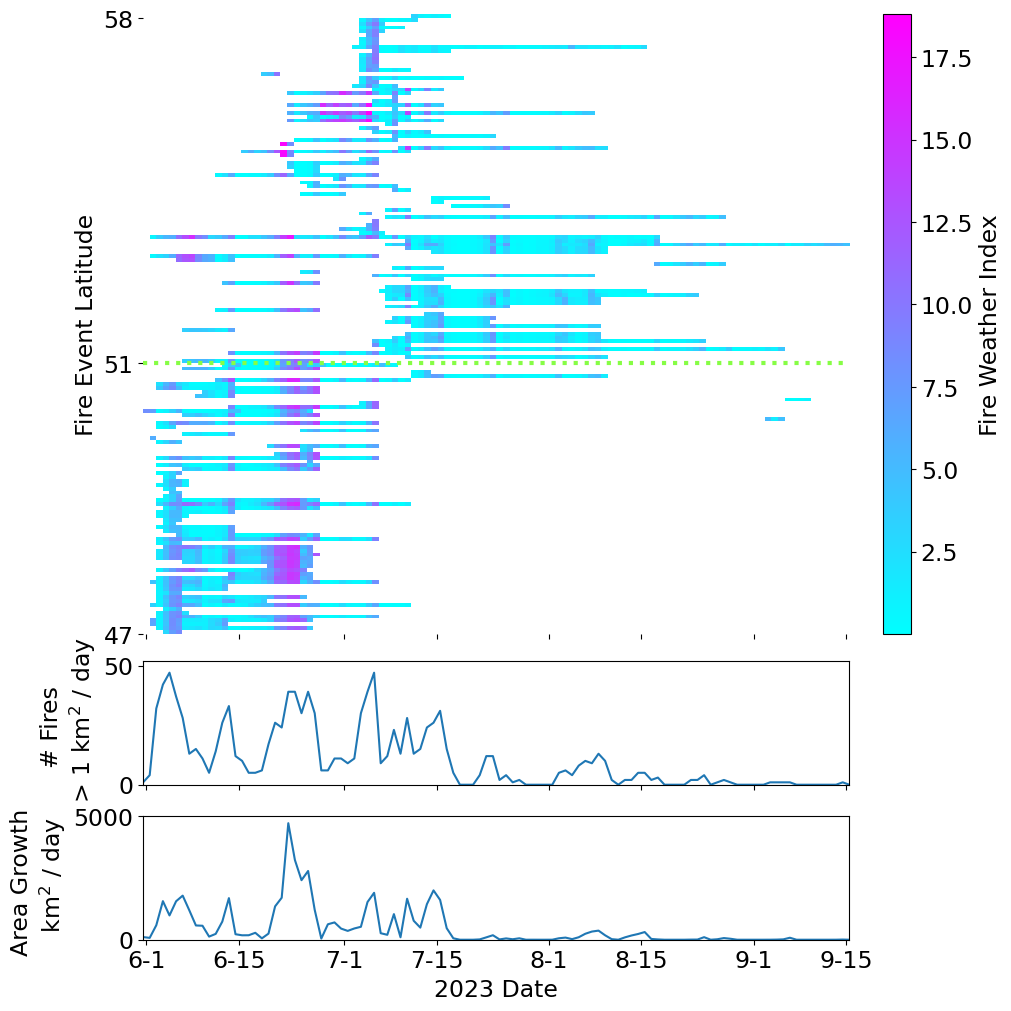

In [51]:
with mpl.rc_context({'font.size': 17}):
    fig1, ([ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(3, 2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [5, 1, 1]}, figsize=(10, 10), constrained_layout=True)
    
    # FIRST: Plot the datetime-based plots to establish the coordinate system
    ax7.plot(num_fr.t.astype("datetime64[ns]"), num_fr.Num_fire_spreading_1km2)
    ax7.set_ylabel("# Fires \n > 1 km$^2$ / day")
    ax7.set_ylim(top=(num_fr.Num_fire_spreading_1km2.max() + 5), bottom=0)
    
    ax9.plot(sum_growth.t.astype("datetime64[ns]"), sum_growth.farea_diff)
    ax9.set_ylim(top=(sum_growth.iloc[:, 1:].max().iloc[0] + 300), bottom=0)
    ax9.set_ylabel("Area Growth \n km$^2$ / day")
    ax9.set_xlabel("2023 Date")
    
    # Share the datetime axes first
    ax9.sharex(ax7)
    
    # Now force ax5 to use the same datetime coordinate system BEFORE creating heatmap
    ax5.sharex(ax7)
    
    # Get the datetime limits
    xlim = ax7.get_xlim()
    
    # Convert heatmap data to work with datetime coordinates
    import matplotlib.dates as mdates
    
    # Convert your date range to matplotlib date numbers
    start_date = num_fr.t.min()
    end_date = num_fr.t.max()
    start_num = mdates.date2num(start_date)
    end_num = mdates.date2num(end_date)
    
    # Create the heatmap with proper extent
    im = ax5.imshow(get_fwi[0].values, 
                    cmap="cool", 
                    aspect='auto',
                    extent=[start_num, end_num, 0, len(get_fwi[0].index)],
                    interpolation='nearest')
    
    # Create the colorbar
    plt.colorbar(im, cax=ax6, label='Fire Weather Index')
    
    # Set up the datetime formatting for ax5
    ax5.xaxis_date()
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    
    # === ADD YOUR CUSTOM Y-AXIS AND HORIZONTAL LINE ===
    
    # Calculate average suppression boundary
    average_suppressionBoundary = (zones.geometry[0].bounds[1] + zones.geometry[0].bounds[3])/2
    print(f"Average suppression boundary is {average_suppressionBoundary}")
    
    # Get the y-axis labels (these will be different now since we're using imshow)
    # We need to map the latitude values from get_fwi[0].index to the imshow coordinates
    
    # Create y-tick positions based on the heatmap data
    y_positions = np.linspace(0, len(get_fwi[0].index), len(get_fwi[0].index))
    y_positions = list(reversed(y_positions))
    latitude_values = get_fwi[0].index.values.astype(float)
    
    # Set the y-ticks to show actual latitude values
    ax5.set_yticks(y_positions[::len(y_positions)//5])  # Show every 5th tick or so
    ax5.set_yticklabels(latitude_values[::len(latitude_values)//5])
    
    # Calculate the horizontal line position
    # Find the position in the imshow coordinates that corresponds to your target latitude
    foo = zones_avg_line.geometry.iloc[0].coords.xy
    target_value = foo[1][1]
    
    # Interpolate to find the y-position for the horizontal line
    interpolated_pos = interpolate_position(
        target_value, 
        latitude_values,
        y_positions
    )
    
    # Add the horizontal line
    ax5.axhline(y=interpolated_pos, color="#86fd45", linestyle="dotted", linewidth=3)
    
    # Custom y-axis labeling (your original logic adapted for imshow)
    ts = latitude_values.astype(str)
    ts_diff = [float(x) - target_value for x in latitude_values]
    new_df = pd.DataFrame({'diff_num': ts_diff, 'y_val': latitude_values})
    new_df.diff_num = new_df.diff_num * new_df.diff_num  # Squaring to get rid of negative values
    mid_val = new_df[new_df.diff_num == new_df.diff_num.min()].y_val.iloc[0]
    
    # Create custom tick labels
    custom_ticks = []
    custom_labels = []
    
    for i, lat_val in enumerate(list(reversed(latitude_values))):
        if (lat_val == mid_val) or (lat_val == latitude_values.max()) or (lat_val == latitude_values.min()):
            custom_ticks.append(i)
            custom_labels.append(str(round(lat_val)))
    
    # Set the custom y-ticks
    ax5.set_yticks(custom_ticks)
    ax5.set_yticklabels(custom_labels)
    
    print("After setting up datetime coordinates:")
    print(f"ax5 xlim: {ax5.get_xlim()}")
    print(f"ax7 xlim: {ax7.get_xlim()}")
    print(f"ax9 xlim: {ax9.get_xlim()}")
    
    # Hide x-tick labels for top plots
    ax5.tick_params(axis='x', labelbottom=False)
    ax7.tick_params(axis='x', labelbottom=False)
    
    # Set axis labels
    ax5.set(xlabel="", ylabel="Fire Event Latitude")
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.spines['bottom'].set_visible(False)
    ax5.spines['left'].set_visible(False)
    
    # Remove unnecessary axes
    ax8.remove()
    ax10.remove()
    plt.savefig(f"some_figs/model_line_too_Number_of_fires_growing_over_1km2_Regional_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)
    plt.show()

### Look at % of total area by extreme weather

In [40]:
# fwi_thresh = 7
# fwi_var = "FWI"

# def get_area_fire(fires):
#     fires = fires.sort_values(by = "t")
#     fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop = True)
#     # fires["farea_diff"] = fires.groupby("fireID").farea.diff()
#     # fires["farea_diff_round"] = fires.farea_diff.round(4) ### Eliminate negligable netative changes
    
#     #ignition_area = fires[fires.farea_diff.isna()].groupby("fireID").farea.sum().reset_index() ## Represents the first observation per fire
#     ignition_area = fires[fires.farea_diff.isna()].groupby("fireID").farea_diff.sum().reset_index()
#     ignition_area = ignition_area.rename(columns = {"farea_diff":"ig"})

#     # merge_ignition_area = fires[fires.farea_diff_round < 0].groupby("fireID").farea.sum().reset_index() ## Represents the moment that new fire was merged into the id -- secondary ignition
#     # merge_ignition_area = merge_ignition_area.rename(columns = {"farea":"merge_ig"}) ## Sceondary ignition seems to not be a thing-- most were just fires that FEDS assumed to be out that got assigned a new ID
    
#     merge_ignition_area = fires[fires.farea_diff_round < 0].groupby("fireID").farea_diff.sum().reset_index() 
#     merge_ignition_area = merge_ignition_area.rename(columns = {"farea_diff":"merge_ig"})
#     #merge_ignition_area = merge_ignition_area.rename(columns = {"farea":"merge_ig"}) 
#     #merge_ignition_area.merge_ig = 0

    
#     difference_area = fires[fires.farea_diff_round >= 0].groupby("fireID").farea_diff.sum().reset_index()
#     difference_area=difference_area.rename(columns = {"farea_diff":"diff_area"})

#     final_area = ignition_area.merge(merge_ignition_area, on = "fireID", how = "outer")
#     final_area = final_area.merge(difference_area, on = "fireID", how = "outer")
    
#     final_area.loc[final_area.ig.isna(),['ig']] = 0
#     final_area.loc[final_area.merge_ig.isna(), ["merge_ig"]] = 0
#     final_area.loc[final_area.diff_area.isna(), ["diff_area"]] = 0
#     final_area.loc[final_area.farea_diff.isna(), ["farea_diff"]] = 0
    
#     #final_area["farea_tot"] = final_area.ig + final_area.merge_ig + final_area.diff_area
#     final_area['farea_tot'] = fires.groupby('fireID').farea_diff.sum()
    

#     return(final_area)

In [41]:
# remerged = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)

# remerged = remerged.to_crs(4326).groupby("fireID").apply(get_centroid).reset_index(drop = True)
# ### Subset by region of quebec

# prov = fv.ca_prov()
# prov = prov[prov.prov_name_en == "Quebec"]

# remerged = remerged.to_crs(4326)
# remerged = remerged.sjoin(prov)

# remerged = remerged.to_crs(3571)

# cp_remerged = average_var_from_multiple_fires(remerged)

# final_area = get_area_fire(cp_remerged)

# high_fwi = get_area_fire(cp_remerged[cp_remerged[fwi_var] >= fwi_thresh])

# per_fire = final_area.merge(high_fwi, on = "fireID",  how = "outer", suffixes = [None, "_fwi"]) ## x is high_fwi


# for n in final_area.columns[1:]:
#     per_fire[n+"_pct"] = per_fire[n + "_fwi"] /per_fire[n]

# per_fire.loc[per_fire.farea_tot_pct.isna(),["farea_tot_pct"]] = 0
# #### print useful statements








# per_fire.fireID.unique()

## Writing the text for fire growth, percentage on spread days

In [42]:
fire3 = fv.formatting_read_in("data/Quebec_v3_full_data_perimeters20241112.csv", start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True )

def calc_spread_day_percentage(df, col = "spread_bool_100"):

    if(df.columns.isin(['index_right']).any()):
        df = df = df.drop('index_right', axis=1)
        
    df = df.drop_duplicates()

    spread_area_no_igs = df[df[col] == 1].farea_diff_stand.sum()
    
    
    ig_area = df[df.t == df.t.min()].farea.iloc[0]
    if(ig_area > 1):
        ig_area_1km = ig_area
        ig_area_less_1km = 0
    else:
        ig_area_1km = 0
        ig_area_less_1km = ig_area
    
    spread_area = df[df[col] == 1].farea_diff_stand.sum() + ig_area_1km
    non_spread_area_no_igs = df[df[col] == 0].farea_diff_stand.sum()
    non_spread_area = df[df[col] == 0].farea_diff_stand.sum() + ig_area_less_1km

    sum_check = df.farea.max() - (spread_area_no_igs + non_spread_area_no_igs + ig_area_1km + ig_area_less_1km)
    if(round(sum_check, 4) != 0):
        print(f" Values not summing to 1 for {df.fireID.unique()} max area {df.farea.max()} - ({spread_area_no_igs}  + {ig_area_1km} + {ig_area_less_1km} + {non_spread_area_no_igs}) = {sum_check}") # + {ig_area}
        return(np.nan)
    else:
        new_df = pd.DataFrame({"area_during_spread_day": [spread_area], "area_during_spread_day_no_igs": [spread_area_no_igs],  "ig_area_1km": [ig_area_1km], "ig_area_less_1km": [ig_area_less_1km],  "non_spread_day_area": [non_spread_area],  "non_spread_day_area_no_igs": [non_spread_area_no_igs], "total_area": [df.farea.max()]}, )
        return(new_df)
    

percent_spread = fire3.groupby("fireID").apply(calc_spread_day_percentage)

/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
/srv/conda/envs/not

In [43]:
# def get_ig_farea_diff_stand(df):
#     return(df[df.t == df.t.min()].spread_bool.iloc[0])

# check_how_ig_read_in_by_bool = fire3.groupby("fireID").apply(get_ig_farea_diff_stand)

print(f'Total number of fires : {len(percent_spread.index.unique())}')

print(f'''
I count the ingnition area as a spread-day if it is larger than 1km^2. That means that some fires had no spread during non-spread days. {len(percent_spread[percent_spread.non_spread_day_area == 0].index.unique())} fires spread only during 1km^2 or lerger increments, and {len(percent_spread[percent_spread.non_spread_day_area != 0].index.unique())} had some area from non-spread days. 
Most of the area came from spread-days (both the first observation and subsequent) in total {(percent_spread.area_during_spread_day.sum() ) / percent_spread.total_area.sum()} percent, or {percent_spread.area_during_spread_day.sum()} km^2. {percent_spread.non_spread_day_area.sum()} occured during non-spread day events. 
Of that, {(percent_spread.ig_area_1km.sum() + percent_spread.ig_area_less_1km.sum()) / percent_spread.total_area.sum()} percent came from the first observation, or {(percent_spread.ig_area_1km.sum() + percent_spread.ig_area_less_1km.sum())} km^2.
On average, fires had {np.mean(percent_spread.area_during_spread_day / percent_spread.total_area)} percent (var {np.var(percent_spread.area_during_spread_day / percent_spread.total_area)}) area occur on in 1km2 increments and {np.mean(percent_spread.non_spread_day_area / percent_spread.total_area)} percent area  (var {np.var(percent_spread.non_spread_day_area / percent_spread.total_area)})in a lesser increment. 


''')


Total number of fires : 160

I count the ingnition area as a spread-day if it is larger than 1km^2. That means that some fires had no spread during non-spread days. 45 fires spread only during 1km^2 or lerger increments, and 115 had some area from non-spread days. 
Most of the area came from spread-days (both the first observation and subsequent) in total 0.9975661758480511 percent, or 49950.5974682572 km^2. 121.86757476934258 occured during non-spread day events. 
Of that, 0.018019167443210794 percent came from the first observation, or 902.2641319046143 km^2.
On average, fires had 0.9669741229414498 percent (var 0.0036624932020726544) area occur on in 1km2 increments and 0.033025877058550035 percent area  (var 0.0036624932020726552)in a lesser increment. 





In [44]:
# print(f"By early June {len(clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-02 00:00:00')].fireID.unique())} fires had started, {len(clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-02 00:00:00') & (clean_df.lat_centroid <= average_suppressionBoundary)].fireID.unique())} in the south of quebec.")

In [45]:
# print(f" The fires started in the north, and grew dramatically to {clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-10 12:00:00') & (clean_df.lat_centroid >= average_suppressionBoundary)].groupby('fireID').farea.max()} and Km^2")

In [46]:




# print(f'There were a total of {len(final_area.fireID.unique())} fires, for a total of {final_area.farea_tot.sum().round()} km^2. ')

# print(f"Of that total, {np.round((high_fwi.farea_tot.sum() / final_area.farea_tot.sum()) * 100)} percent of the area was when {fwi_var} was >= than {fwi_thresh}")

# print(f"Per fire, on average {per_fire.farea_tot_pct.mean()}of the area came from when {fwi_var} was >= than {fwi_thresh}, or a median of {np.round(per_fire.farea_tot_pct.median(), 2)}, with 0.025 being {per_fire.farea_tot_pct.quantile(0.025)} and 0.975 being {per_fire.farea_tot_pct.quantile(0.975)} ")

In [47]:
# max_fr_area

# Add variance to the avaraged timeserise plots



In [48]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_MEAN.csv')

FWI_data_south_75 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_75.csv')
FWI_data_south_25 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_25.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_MEAN.csv')
FWI_data_north_75 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_75.csv')
FWI_data_north_25 = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_25.csv')

Text(0, 0.5, 'FWI')

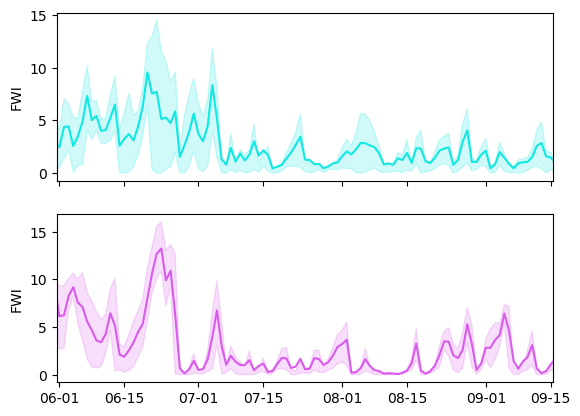

In [49]:
fig, (ax, ax2) = plt.subplots(2, gridspec_kw={'height_ratios': [1, 1]}, sharex = True)
#fig.suptitle('Aligning x-axis using sharex')



ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.plot(FWI_data_north.INITDATE.astype("datetime64[ns]"),FWI_data_north['GEOS-5.IMERGEARLY'], color = "#12e8e2")
ax.fill_between(FWI_data_north_75.INITDATE.astype("datetime64[ns]"), FWI_data_north_75['GEOS-5.IMERGEARLY'], FWI_data_north_25['GEOS-5.IMERGEARLY'], color = "#12e8e2",  alpha = 0.2)
ax.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())

ax.set_ylabel("FWI")

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.plot(FWI_data_south.INITDATE.astype("datetime64[ns]"),FWI_data_south['GEOS-5.IMERGEARLY'], color = "#d85beb")
ax2.fill_between(FWI_data_south_75.INITDATE.astype("datetime64[ns]"), FWI_data_south_75['GEOS-5.IMERGEARLY'], FWI_data_south_25['GEOS-5.IMERGEARLY'], color = "#d85beb",  alpha = 0.2)
#ax2.set_xlim(no_dupes[no_dupes.t == '2023-07-01 12:00:00'].t.max(), no_dupes[no_dupes.t == '2023-08-01 12:00:00'].t.max())
ax2.set_xlim(no_dupes[no_dupes.t == '2023-05-31 12:00:00'].t.max(), no_dupes[no_dupes.t == '2023-09-15 12:00:00'].t.max())
ax2.set_ylabel("FWI")

# Make the Canada Inset for Figure 1

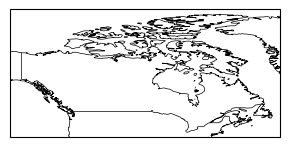

In [50]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(3, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

# Add Canada boundaries and features
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Set extent for Canada
ax.set_extent([-145, -50, 40, 85], crs=ccrs.PlateCarree())

# If you have provincial boundary data, highlight Quebec
# This would require Canadian provincial boundary shapefiles
# You can download from Statistics Canada or Natural Earth

#ax.set_title('Canada', fontsize=8)
plt.tight_layout()
plt.savefig('canada_inset.png', dpi=300, bbox_inches='tight')